In [1]:
using DifferentialEquations, Plots, LinearAlgebra

In [2]:
p_cr = 33
tau1 = 22
p1 = 7.7
tau2 = 13
p2 = 10.7
N = 44
q = 1

a1 = p_cr/(tau1*tau1*p1*p1*N*q)
a2 = p_cr/(tau2*tau2*p2*p2*N*q)
b = p_cr/(tau1*tau1*p1*p1*tau2*tau2*p2*p2*N*q)
c1 = (p_cr -p1)/(tau1*p1)
c2 = (p_cr-p2)/(tau2*p2)

u0 = [4.4, 3.1]
p = [a1, a2, b, c1, c2]
tspan = (0.0, 50.0)

(0.0, 50.0)

In [3]:
function f(u,p,t)
	M1, M2 = u
	a1, a2, b, c1, c2 = p
	M1 = M1 - (b/c1)*M1*M2 - (a1/c1)*M1*M1
	M2 = (c2/c1)*M2 - (b/c1)*M1*M2 - (a2/c1)*M2*M2
	return [M1, M2]
end

A = [(a1/c1) (b/c1); (b/c1) (a2/c1)]
b1 = [1, (c2/c1)]
x = A \ b1
println(x)

[5714.212921865828, 4135.707539916032]


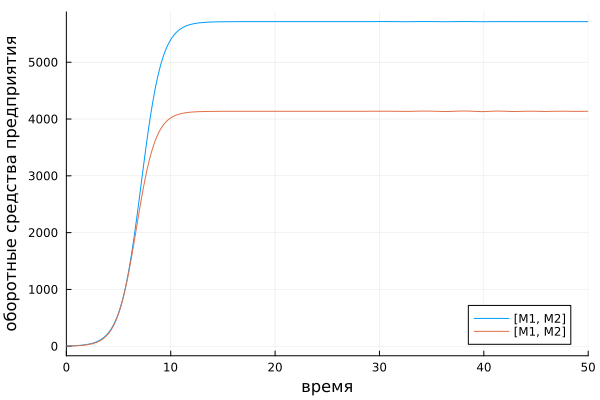

In [4]:
prob = ODEProblem(f, u0, tspan, p)
sol = solve(prob, Tsit5(), saveat=0.01)
plot(sol, yaxis="оборотные средства предприятия", xaxis="время", label="[M1, M2]")
#savefig("first_case.png")

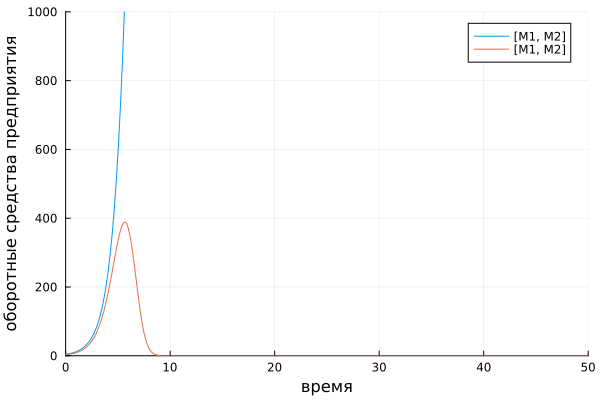

In [12]:
function f2(du, u, p, t)
	a1, a2, b, c1, c2 = p
	du[1] = u[1] - (a1/c1)*u[1]*u[1] - (b/c1)*u[1]*u[2]
	du[2] = (c2/c1)*u[2] - (b/c1+0.00094)*u[1]*u[2] - (a2/c1)*u[2]*u[2]
end


prob2 = ODEProblem(f2, u0, tspan, p)
sol2 = solve(prob2, Tsit5(), saveat=0.01)
plot(sol2, yaxis="оборотные средства предприятия", xaxis="время", label="[M1, M2]", ylimit=[0, 1000], xlimit=[0,50])
#savefig("second_case.png")

Final M2 values:
sol: 4135.428585530667
sol2: 1.334587647931057e-7

Maximum M2 values:
sol: 4140.862562006488
sol2: 388.01919801384605

Minimum M2 values:
sol: 3.1
sol2: -7.93379187879908e-7
